### Install the necessary libraries

In [1]:
%pip install numpy
%pip install matplotlib
%pip install torch
%pip install torchvision
%pip install einops

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Note: you may need to restart the kernel to use updated packages.


### Import all the necessary libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, einsum
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Machine Problem 1: 3-layer CNN on MNIST using einops and einsum
- Build a 3-layer CNN for MNIST classification with every layer and operation implemented using einops/einsum
- Train the model for 5 epochs and report the test split accuracy
- Sample 16 images and put them in a 4x4 grid together with the ground truth and the prediction

The convolution, pooling, flatten, linear layer and cross entropy loss are all written from scratch below. Nothing from `torch.nn` is used as a layer, so there is no `nn.Conv2d`, `nn.Linear`, `nn.MaxPool2d`, `F.conv2d` and no `F.unfold`. What is taken from PyTorch is autograd for the backward pass, the Adam optimizer, tensor padding and the data loaders.

### Set the device, the random seed and the hyperparameters

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(42)
np.random.seed(42)

batch_size = 128
epochs = 5
learning_rate = 1e-3

print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


### Load the MNIST dataset and normalize using the dataset mean and standard deviation

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training instances: {len(train_dataset)}")
print(f"Test instances: {len(test_dataset)}")
print(f"Image shape: {tuple(train_dataset[0][0].shape)}")

Training instances: 60000
Test instances: 10000
Image shape: (1, 28, 28)


#### Implement the convolution layer using a sliding window view and einsum

A convolution is a dot product between the kernel and every sliding window of the input, so it is a single contraction once the windows are laid out as a matrix. `Tensor.unfold` produces the sliding windows as a zero copy view, `rearrange` flattens each window and each kernel into one vector, and `einsum` contracts them:

`b (c kh kw) (oh ow)` and `o (c kh kw)` gives `b o (oh ow)`

`Tensor.unfold` is used instead of `F.unfold` because it is a generic strided window view that works on any tensor, so no convolution specific helper is borrowed.

In [5]:
def conv2d_einsum(x, weight, bias, stride=1, padding=1):
    kh, kw = weight.shape[-2:]
    x = F.pad(x, (padding, padding, padding, padding))

    windows = x.unfold(2, kh, stride).unfold(3, kw, stride)
    patches = rearrange(windows, 'b c oh ow kh kw -> b (c kh kw) (oh ow)')
    weight_mat = rearrange(weight, 'o c kh kw -> o (c kh kw)')

    out = einsum(patches, weight_mat, 'b p l, o p -> b o l') + rearrange(bias, 'o -> 1 o 1')
    out_h = (x.shape[2] - kh) // stride + 1
    return rearrange(out, 'b o (oh ow) -> b o oh ow', oh=out_h)

#### Implement max pooling, global average pooling, flatten and the linear layer using einops

Max pooling splits each spatial axis into tiles with the pattern `(h p1) (w p2)` and reduces over the tile axes. Global average pooling removes the spatial axes completely. The linear layer is a contraction over the feature axis.

In [6]:
def maxpool2d_einops(x, size=2):
    return reduce(x, 'b c (h p1) (w p2) -> b c h w', 'max', p1=size, p2=size)


def global_avg_pool_einops(x):
    return reduce(x, 'b c h w -> b c', 'mean')


def flatten_einops(x):
    return rearrange(x, 'b c h w -> b (c h w)')


def linear_einsum(x, weight, bias):
    return einsum(x, weight, 'b i, o i -> b o') + bias

#### Implement ReLU and the cross entropy loss

ReLU is elementwise so there is no axis pattern to write. The cross entropy uses the log sum exp form for numerical stability, and `einsum` picks out the log probability of the correct class by contracting against a one hot matrix.

In [7]:
def relu(x):
    return x.clamp(min=0)


def cross_entropy_einops(logits, targets):
    log_probs = logits - torch.logsumexp(logits, dim=1, keepdim=True)

    classes = torch.arange(logits.shape[1], device=logits.device)
    one_hot = (rearrange(targets, 'b -> b 1') == classes).to(logits.dtype)

    picked = einsum(log_probs, one_hot, 'b k, b k -> b')
    return -reduce(picked, 'b -> ', 'mean')

#### Verify all the custom operations against the PyTorch reference implementations

The checks run in double precision so the difference reflects the implementation and not the floating point format. A correct implementation lands at machine precision, around `1e-14` or smaller.

In [8]:
torch.manual_seed(0)

x_ref = torch.randn(8, 3, 12, 12, dtype=torch.float64)
w_ref = torch.randn(6, 3, 3, 3, dtype=torch.float64)
b_ref = torch.randn(6, dtype=torch.float64)
y_ref = torch.randn(8, 6, 12, 12, dtype=torch.float64)
v_ref = torch.randn(8, 16, dtype=torch.float64)
fc_w = torch.randn(10, 16, dtype=torch.float64)
fc_b = torch.randn(10, dtype=torch.float64)
logits_ref = torch.randn(8, 10, dtype=torch.float64)
targets_ref = torch.randint(0, 10, (8,))

checks = {
    'conv2d': (conv2d_einsum(x_ref, w_ref, b_ref), F.conv2d(x_ref, w_ref, b_ref, stride=1, padding=1)),
    'maxpool2d': (maxpool2d_einops(y_ref), F.max_pool2d(y_ref, 2)),
    'global avg pool': (global_avg_pool_einops(y_ref), F.adaptive_avg_pool2d(y_ref, 1).squeeze(-1).squeeze(-1)),
    'flatten': (flatten_einops(y_ref), y_ref.reshape(y_ref.shape[0], -1)),
    'linear': (linear_einsum(v_ref, fc_w, fc_b), F.linear(v_ref, fc_w, fc_b)),
    'relu': (relu(y_ref), F.relu(y_ref)),
    'cross entropy': (cross_entropy_einops(logits_ref, targets_ref), F.cross_entropy(logits_ref, targets_ref)),
}

print(f"\n{'='*60}")
for name, (mine, reference) in checks.items():
    diff = (mine - reference).abs().max().item()
    assert diff < 1e-10, f"{name} does not match the reference"
    print(f"{name:20s} max abs difference vs torch: {diff:.3e}")
print(f"{'='*60}")


conv2d               max abs difference vs torch: 1.066e-14
maxpool2d            max abs difference vs torch: 0.000e+00
global avg pool      max abs difference vs torch: 0.000e+00
flatten              max abs difference vs torch: 0.000e+00
linear               max abs difference vs torch: 0.000e+00
relu                 max abs difference vs torch: 0.000e+00
cross entropy        max abs difference vs torch: 4.441e-16


#### Define the 3-layer CNN using the custom operations and initialize the weights using He initialization

Three convolution layers with a linear classifier head. Global average pooling replaces the usual flatten before the head, which keeps the classifier small. `nn.Parameter` is only used to register the tensors with the optimizer, the layers themselves are the functions written above.

```
Input                1 x 28 x 28
Conv1  1  -> 32   3x3  ReLU  MaxPool 2x2   ->  32 x 14 x 14
Conv2  32 -> 64   3x3  ReLU  MaxPool 2x2   ->  64 x 7 x 7
Conv3  64 -> 128  3x3  ReLU  GlobalAvgPool ->  128
Linear 128 -> 10                           ->  logits
```

In [9]:
def he_init(*shape):
    fan_in = int(np.prod(shape[1:]))
    return torch.randn(*shape) * np.sqrt(2.0 / fan_in)


class EinopsCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.w1 = nn.Parameter(he_init(32, 1, 3, 3))
        self.b1 = nn.Parameter(torch.zeros(32))
        self.w2 = nn.Parameter(he_init(64, 32, 3, 3))
        self.b2 = nn.Parameter(torch.zeros(64))
        self.w3 = nn.Parameter(he_init(128, 64, 3, 3))
        self.b3 = nn.Parameter(torch.zeros(128))
        self.w_fc = nn.Parameter(he_init(num_classes, 128))
        self.b_fc = nn.Parameter(torch.zeros(num_classes))

    def forward(self, x):
        x = maxpool2d_einops(relu(conv2d_einsum(x, self.w1, self.b1)))
        x = maxpool2d_einops(relu(conv2d_einsum(x, self.w2, self.b2)))
        x = relu(conv2d_einsum(x, self.w3, self.b3))
        x = global_avg_pool_einops(x)
        return linear_einsum(x, self.w_fc, self.b_fc)

#### Show the shape after every layer and the number of parameters

In [10]:
model = EinopsCNN().to(device)

sample = train_dataset[0][0].unsqueeze(0).to(device)
with torch.no_grad():
    h1 = maxpool2d_einops(relu(conv2d_einsum(sample, model.w1, model.b1)))
    h2 = maxpool2d_einops(relu(conv2d_einsum(h1, model.w2, model.b2)))
    h3 = relu(conv2d_einsum(h2, model.w3, model.b3))
    h4 = global_avg_pool_einops(h3)
    out = linear_einsum(h4, model.w_fc, model.b_fc)

print(f"input                 {tuple(sample.shape)}")
print(f"conv1 + relu + pool   {tuple(h1.shape)}")
print(f"conv2 + relu + pool   {tuple(h2.shape)}")
print(f"conv3 + relu          {tuple(h3.shape)}")
print(f"global average pool   {tuple(h4.shape)}")
print(f"linear                {tuple(out.shape)}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

input                 (1, 1, 28, 28)
conv1 + relu + pool   (1, 32, 14, 14)
conv2 + relu + pool   (1, 64, 7, 7)
conv3 + relu          (1, 128, 7, 7)
global average pool   (1, 128)
linear                (1, 10)

Total trainable parameters: 93,962


#### Train the model for 5 epochs using Adam and evaluate on the test split after every epoch

In [11]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images).argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct, total


optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        loss = cross_entropy_einops(model(images), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)
    correct, total = evaluate(model, test_loader)
    print(f"Epoch {epoch}/{epochs}   train loss: {train_loss:.4f}   test accuracy: {correct / total:.4f}")

Epoch 1/5   train loss: 0.5839   test accuracy: 0.9585


Epoch 2/5   train loss: 0.1429   test accuracy: 0.9670


Epoch 3/5   train loss: 0.0992   test accuracy: 0.9738


Epoch 4/5   train loss: 0.0769   test accuracy: 0.9782


Epoch 5/5   train loss: 0.0598   test accuracy: 0.9809


#### Report the accuracy on the full test split

In [12]:
correct, total = evaluate(model, test_loader)
test_accuracy = correct / total

print(f"\n{'='*60}")
print(f"Test split accuracy after {epochs} epochs: {test_accuracy * 100:.2f}%")
print(f"Correctly classified: {correct} out of {total}")
print(f"{'='*60}")


Test split accuracy after 5 epochs: 98.09%
Correctly classified: 9809 out of 10000


##### A. The 3-layer CNN reaches a test split accuracy of **98.09%** after 5 epochs, which is 9809 correctly classified images out of the 10000 in the test split. The accuracy was still improving at the last epoch, going from 97.38% at epoch 3 to 98.09% at epoch 5, so the model is limited by the 5 epoch budget rather than by capacity. Every operation in the network was verified against the PyTorch reference implementation before training, with a maximum difference of `1.07e-14`, so the accuracy comes from a convolution that is numerically identical to `F.conv2d`.

#### Sample 16 images from the test split and display them in a 4x4 grid together with the ground truth and the prediction

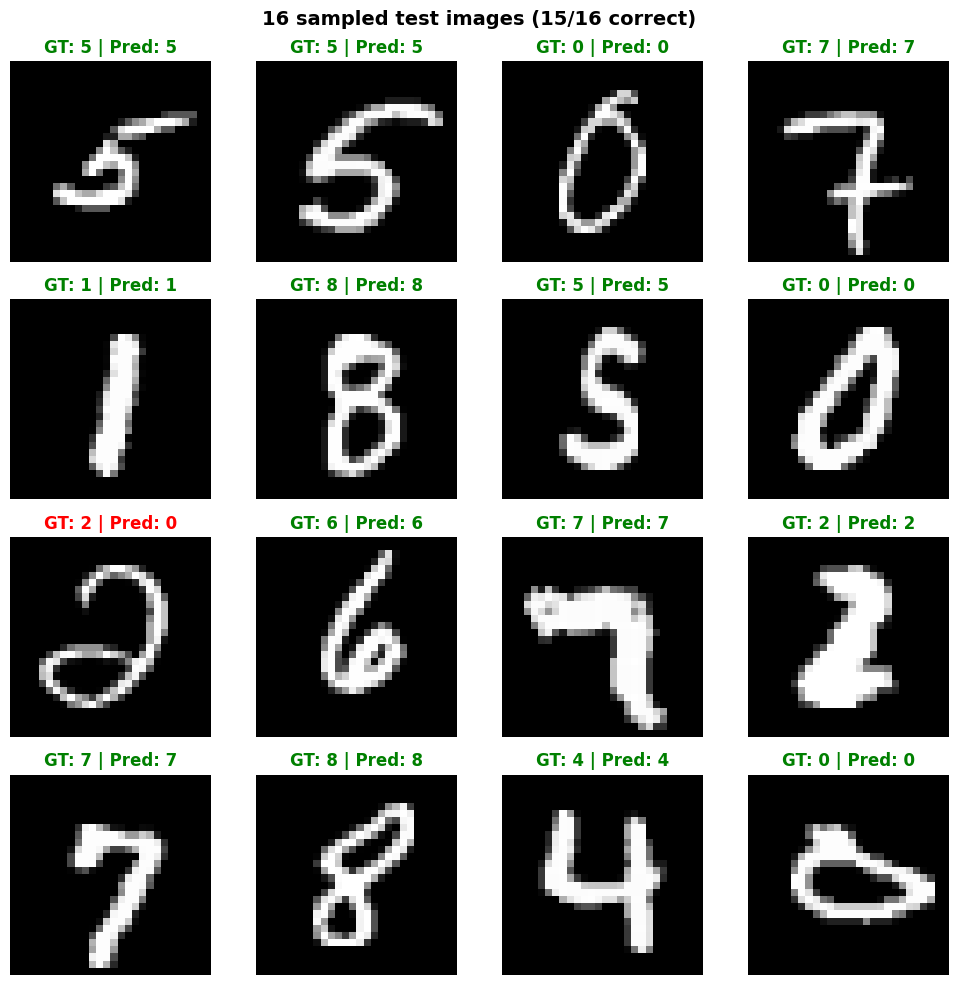

In [13]:
generator = torch.Generator().manual_seed(42)
sample_indices = torch.randperm(len(test_dataset), generator=generator)[:16]

sample_images = torch.stack([test_dataset[i][0] for i in sample_indices])
sample_labels = torch.tensor([test_dataset[i][1] for i in sample_indices])

model.eval()
with torch.no_grad():
    sample_predictions = model(sample_images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for ax, image, label, prediction in zip(axes.ravel(), sample_images, sample_labels, sample_predictions):
    ax.imshow(image.squeeze() * 0.3081 + 0.1307, cmap='gray')
    ax.set_title(f'GT: {label.item()} | Pred: {prediction.item()}', fontsize=12, fontweight='bold',
                 color='green' if prediction == label else 'red')
    ax.axis('off')

fig.suptitle(f'16 sampled test images ({(sample_predictions == sample_labels).sum().item()}/16 correct)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### Notes on the einsum formulation

Writing the convolution as `b (c kh kw) (oh ow)` contracted with `o (c kh kw)` makes it clear that a convolution layer is one matrix multiplication over sliding windows, and that the kernel size and the input channels only ever appear together as a single contracted axis. The cost is memory rather than arithmetic, because the window view has to be materialized into a patch matrix that repeats every input pixel `kh * kw` times. This is why the from scratch version runs about six times slower than cuDNN, which fuses the same computation without ever writing the patch matrix out.